## 1. IMPORTACIÓN Y CONFIGURACIÓN

In [178]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime

# Librerías para modelado
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
import optuna

# Configuraciones
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Fecha de análisis: 2025-12-05 21:07


## 2. CARGA DE DATOS PREPARADOS

In [179]:
# Cargar datos del análisis exploratorio
try:
    with open('datasets_preparados.pkl', 'rb') as f:
        datasets = pickle.load(f)
    
    # Extraer datasets
    data = datasets['data']
    train_to1 = datasets['train_to1']
    train_to2 = datasets['train_to2']
    test_to1 = datasets['test_to1']
    test_to2 = datasets['test_to2']
    train_len = datasets['train_len']
    
    print("Datos cargados exitosamente desde análisis exploratorio")
    print(f"Configuración: {train_len} train / {len(data) - train_len} test")
    
except FileNotFoundError:
    print("Error: No se encontró 'datasets_preparados.pkl'")
    print("Ejecuta primero el notebook '01_Analisis_Exploratorio.ipynb'")

Datos cargados exitosamente desde análisis exploratorio
Configuración: 121 train / 6 test


## 3. FUNCIONES DE EVALUACIÓN

In [180]:
# ==================== FUNCIONES PARA MEDIA MÓVIL ====================

def evaluar_media_movil_rolling(train_data, test_data, ventana):
    """
    Evalúa media móvil usando ventana móvil (walking forward)
    Predice solo 1 paso adelante en cada iteración usando datos reales disponibles
    """
    predicciones = []
    datos_disponibles = train_data.copy()
    
    for i in range(len(test_data)):
        # Predecir solo el siguiente período usando los últimos 'ventana' datos reales
        prediccion = datos_disponibles.iloc[-ventana:].mean()
        if isinstance(prediccion, pd.Series):
            prediccion = prediccion.iloc[0]
        predicciones.append(prediccion)
        
        # Agregar el dato real del test para la siguiente predicción
        valor_real = test_data.iloc[i].values[0]
        nuevo_indice = datos_disponibles.index[-1] + 1
        datos_disponibles.loc[nuevo_indice] = valor_real
    
    return pd.Series(predicciones, index=test_data.index)


def pronosticar_media_movil(datos, ventana, horizonte):
    """
    Genera pronósticos futuros usando media móvil
    """
    data = datos.copy()
    
    for i in range(horizonte):
        nuevo_valor = data.iloc[-ventana:].mean()
        if isinstance(nuevo_valor, pd.Series):
            nuevo_valor = nuevo_valor.iloc[0]
        nuevo_indice = data.index[-1] + 1
        data.loc[nuevo_indice] = nuevo_valor
    
    return data.iloc[-horizonte:]


print("Funciones de Media Móvil definidas")

Funciones de Media Móvil definidas


In [181]:
# ==================== FUNCIONES PARA HOLT-WINTERS ====================

def evaluar_rolling_forecast_holtwinters(serie, alpha, beta, gamma, seasonal=None, trend='add',
                                          window_size=60, window=6, step_size=1, 
                                          horizon=1, metric='rmse'):
    """Evalúa Holt-Winters con validación temporal"""
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos, observados = [], []
    
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    for end_train in puntos_finales:
        start_train = max(0, end_train - window_size)
        train = serie.iloc[start_train:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        if len(test) < horizon or len(train) < 12:
            continue
            
        try:
            if seasonal is None:
                # Solo tendencia
                model = ExponentialSmoothing(
                    train, trend=trend, seasonal=None
                ).fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)
            else:
                # Con estacionalidad
                seasonal_periods = min(6, len(train)//2)
                model = ExponentialSmoothing(
                    train, trend=trend, seasonal=seasonal, 
                    seasonal_periods=seasonal_periods
                ).fit(smoothing_level=alpha, smoothing_trend=beta, 
                      smoothing_seasonal=gamma, optimized=False)
            
            pred = model.forecast(steps=horizon)
            if not np.isfinite(pred).all():
                continue
                
            predichos.extend(pred.tolist())
            observados.extend(test.tolist())
                
        except:
            continue
            
    if len(predichos) == 0:
        return np.inf
    
    predichos = np.array(predichos)
    observados = np.array(observados)
    
    if not np.isfinite(predichos).all() or not np.isfinite(observados).all():
        return np.inf
    
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    else:
        return np.mean(np.abs(observados - predichos))


print("Funciones de Holt-Winters definidas")

Funciones de Holt-Winters definidas


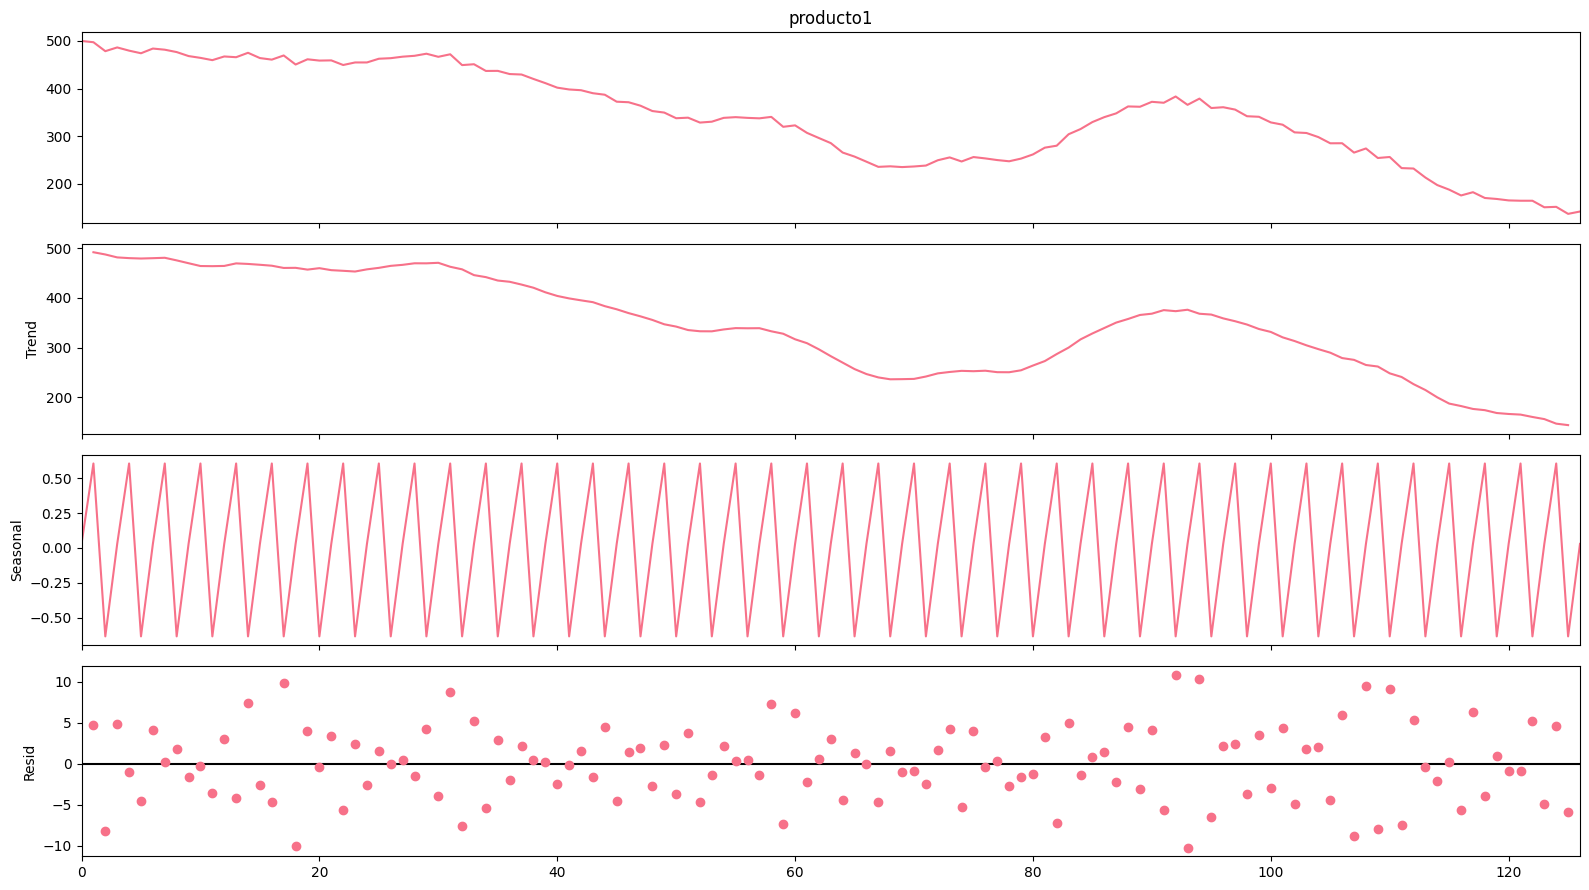

In [182]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use period parameter to specify seasonality (assuming 12 periods for seasonal pattern)
to_componentes = seasonal_decompose(data["producto1"], model="additive", period=3)
fig = to_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

## 4. MEDIA MÓVIL - PRODUCTO 1

In [183]:
## Considerando el dato actual. Números 2,3,4,5 ventanas (datos del más cercano al más lejano para predecir)
ma_2= train_to1.rolling(2,min_periods=2).mean()
ma_3= train_to1.rolling(3,min_periods=2).mean()
ma_4= train_to1.rolling(4,min_periods=2).mean()
ma_5= train_to1.rolling(5,min_periods=2).mean()
ma_6= train_to1.rolling(6,min_periods=2).mean()

In [184]:
## Sin considerar el dato actual, por si el periodo no ha finalizado. Preguntar ¿Cuándo debe correr el modelo?
ma_2= train_to1.shift().rolling(2,min_periods=2).mean()
ma_3= train_to1.shift().rolling(3,min_periods=2).mean()
ma_4= train_to1.shift().rolling(4,min_periods=2).mean()
ma_5= train_to1.shift().rolling(5,min_periods=2).mean()
ma_6= train_to1.shift().rolling(6,min_periods=2).mean()

In [185]:
#Función para tener en cuenta el nuevo promedio con el anterior para realizar el pronóstico. Considerar el forecast que estoy generando.
def fore_ma(datos,w,h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [186]:
# Función para generar pronósticos con índices enteros
def fore_ma_simple(datos, w, h):
	"""
	Versión simplificada de fore_ma para datos con índices enteros
	"""
	data = datos.copy()
	for x in range(1, h+1):
		# Usar el siguiente índice entero en lugar de DateOffset
		nuevo_indice = data.index[-1] + 1
		valor_promedio = data[-w:].mean()
		data.loc[nuevo_indice] = valor_promedio
	return data[-h:]

# Ventana (2,3,4,5,6) y cantidad de pronósticos que voy a generar (1).
ma_2_f = fore_ma_simple(train_to1['producto1'], 2, 1)
ma_3_f = fore_ma_simple(train_to1['producto1'], 3, 1) 
ma_4_f = fore_ma_simple(train_to1['producto1'], 4, 1)
ma_5_f = fore_ma_simple(train_to1['producto1'], 5, 1)
ma_6_f = fore_ma_simple(train_to1['producto1'], 6, 1)

print("Pronósticos de Media Móvil para Producto 1:")
print(f"MA(2): {ma_2_f.iloc[0]:.4f}")
print(f"MA(3): {ma_3_f.iloc[0]:.4f}")
print(f"MA(4): {ma_4_f.iloc[0]:.4f}")
print(f"MA(5): {ma_5_f.iloc[0]:.4f}")
print(f"MA(6): {ma_6_f.iloc[0]:.4f}")

Pronósticos de Media Móvil para Producto 1:
MA(2): 166.8015
MA(3): 167.9977
MA(4): 171.6298
MA(5): 172.4451
MA(6): 175.0142


In [187]:
# Seleccionar métrica más baja comparando solo el primer período de prueba
primer_valor_real = test_to1['producto1'].iloc[0]

rmse_ma_2 = abs(primer_valor_real - ma_2_f.iloc[0])
rmse_ma_3 = abs(primer_valor_real - ma_3_f.iloc[0])
rmse_ma_4 = abs(primer_valor_real - ma_4_f.iloc[0])
rmse_ma_5 = abs(primer_valor_real - ma_5_f.iloc[0])
rmse_ma_6 = abs(primer_valor_real - ma_6_f.iloc[0])

print("Errores absolutos para un período adelante:")
print(f"RMSE MA(2): {rmse_ma_2:.4f}")
print(f"RMSE MA(3): {rmse_ma_3:.4f}")
print(f"RMSE MA(4): {rmse_ma_4:.4f}")
print(f"RMSE MA(5): {rmse_ma_5:.4f}")
print(f"RMSE MA(6): {rmse_ma_6:.4f}")

# Encontrar la mejor ventana
errores = [rmse_ma_2, rmse_ma_3, rmse_ma_4, rmse_ma_5, rmse_ma_6]
ventanas_nombres = ['MA(2)', 'MA(3)', 'MA(4)', 'MA(5)', 'MA(6)']
mejor_ventana_simple = ventanas_nombres[errores.index(min(errores))]
print(f"\nMejor método: {mejor_ventana_simple} con error absoluto: {min(errores):.4f}")

Errores absolutos para un período adelante:
RMSE MA(2): 2.1760
RMSE MA(3): 3.3722
RMSE MA(4): 7.0043
RMSE MA(5): 7.8196
RMSE MA(6): 10.3888

Mejor método: MA(2) con error absoluto: 2.1760


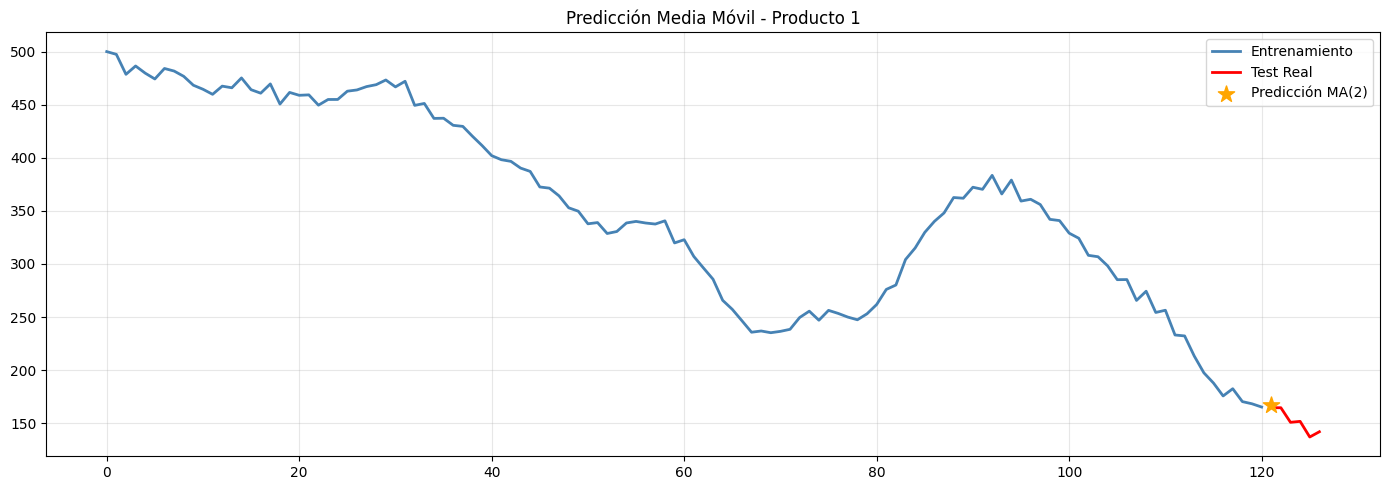

In [188]:
# Visualización simple de predicción MA(2)
fig = plt.figure(figsize=(14, 5))

plt.plot(train_to1.index, train_to1['producto1'], label="Entrenamiento", 
         color='steelblue', linewidth=2)
plt.plot(test_to1.index, test_to1['producto1'], label="Test Real", 
         color='red', linewidth=2)
plt.scatter([test_to1.index[0]], [ma_2_f.iloc[0]], 
            label="Predicción MA(2)", color='orange', s=150, marker='*', zorder=5)

plt.title('Predicción Media Móvil - Producto 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [189]:
# Evaluación con ventana móvil (walking forward) para cada ventana
print("EVALUACIÓN CON VENTANA MÓVIL - PRODUCTO 1")
print("=" * 60)

ventanas_evaluar = [2, 3, 4, 5, 6]
resultados_rmse = {}

for w in ventanas_evaluar:
    predicciones_test = []
    valores_reales = []
    
    # Walking forward sobre el conjunto de test
    for i in range(len(test_to1)):
        # Obtener todos los datos disponibles hasta este punto (train + test ya observados)
        if i == 0:
            datos_disponibles = train_to1['producto1'].copy()
        else:
            datos_disponibles = pd.concat([train_to1['producto1'], test_to1['producto1'].iloc[:i]])
        
        # Predecir usando los últimos w datos
        prediccion = datos_disponibles.iloc[-w:].mean()
        valor_real = test_to1['producto1'].iloc[i]
        
        predicciones_test.append(prediccion)
        valores_reales.append(valor_real)
    
    # Calcular RMSE para esta ventana
    rmse = np.sqrt(mean_squared_error(valores_reales, predicciones_test))
    resultados_rmse[w] = {
        'rmse': rmse,
        'predicciones': predicciones_test,
        'reales': valores_reales
    }
    
    print(f"Ventana MA({w}): RMSE = {rmse:.4f}")

# Encontrar mejor ventana
mejor_ventana = min(resultados_rmse.keys(), key=lambda x: resultados_rmse[x]['rmse'])
print(f"\nMejor ventana: MA({mejor_ventana}) con RMSE = {resultados_rmse[mejor_ventana]['rmse']:.4f}")
print("=" * 60)

EVALUACIÓN CON VENTANA MÓVIL - PRODUCTO 1
Ventana MA(2): RMSE = 8.5543
Ventana MA(3): RMSE = 10.3883
Ventana MA(4): RMSE = 12.1619
Ventana MA(5): RMSE = 13.5507
Ventana MA(6): RMSE = 15.2588

Mejor ventana: MA(2) con RMSE = 8.5543


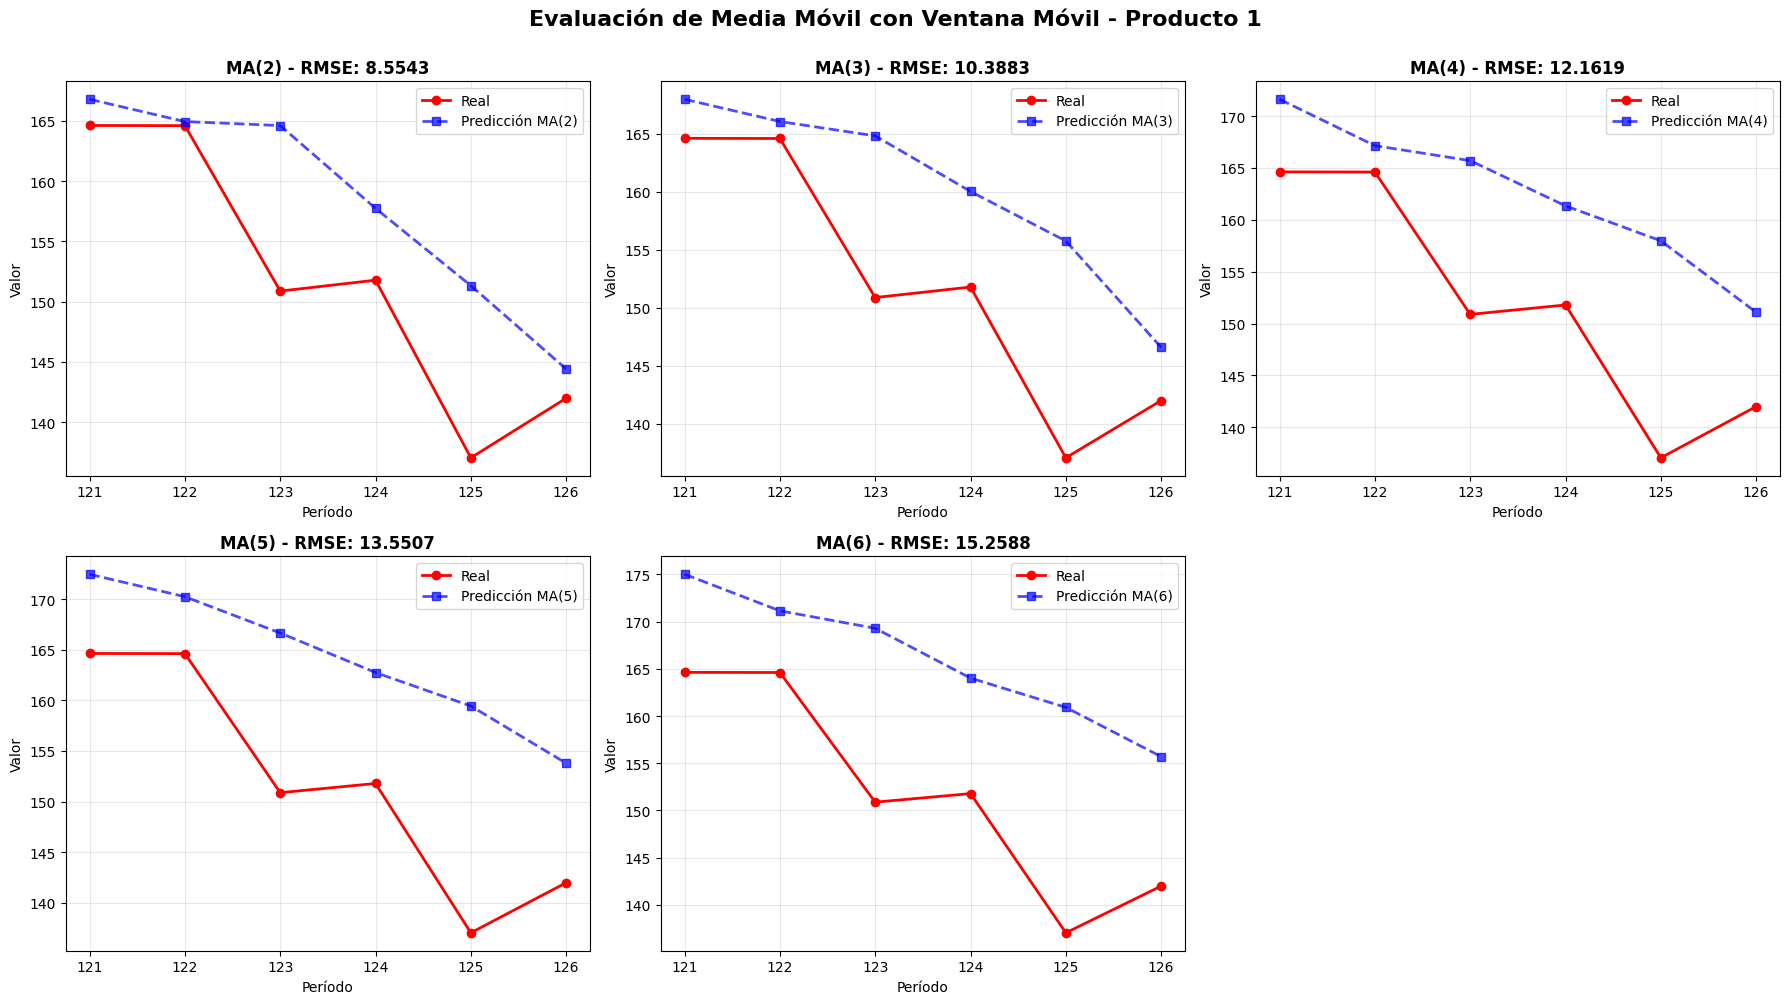

In [190]:
# Visualización de predicciones vs valores reales
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, w in enumerate(ventanas_evaluar):
    ax = axes[idx]
    
    # Plotear valores reales y predicciones
    indices_test = test_to1.index
    ax.plot(indices_test, resultados_rmse[w]['reales'], 
            label='Real', marker='o', linewidth=2, markersize=6, color='red')
    ax.plot(indices_test, resultados_rmse[w]['predicciones'], 
            label=f'Predicción MA({w})', marker='s', linewidth=2, 
            markersize=6, linestyle='--', color='blue', alpha=0.7)
    
    ax.set_title(f'MA({w}) - RMSE: {resultados_rmse[w]["rmse"]:.4f}', fontweight='bold')
    ax.set_xlabel('Período')
    ax.set_ylabel('Valor')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Ocultar subplot extra
axes[5].axis('off')

plt.suptitle('Evaluación de Media Móvil con Ventana Móvil - Producto 1', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5. HOLT-WINTERS - PRODUCTO 1

Suavización exponencial simple

In [191]:
# Build model.
ets_model = ETSModel(endog=train_to1["producto1"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

     Point_forecast    lower_95    upper_95
121      165.274905  145.929652  184.620157
122      165.274905  137.917954  192.631855
123      165.274905  131.770179  198.779631
124      165.274905  126.587302  203.962508
125      165.274905  122.021066  208.528744
126      165.274905  117.892856  212.656953


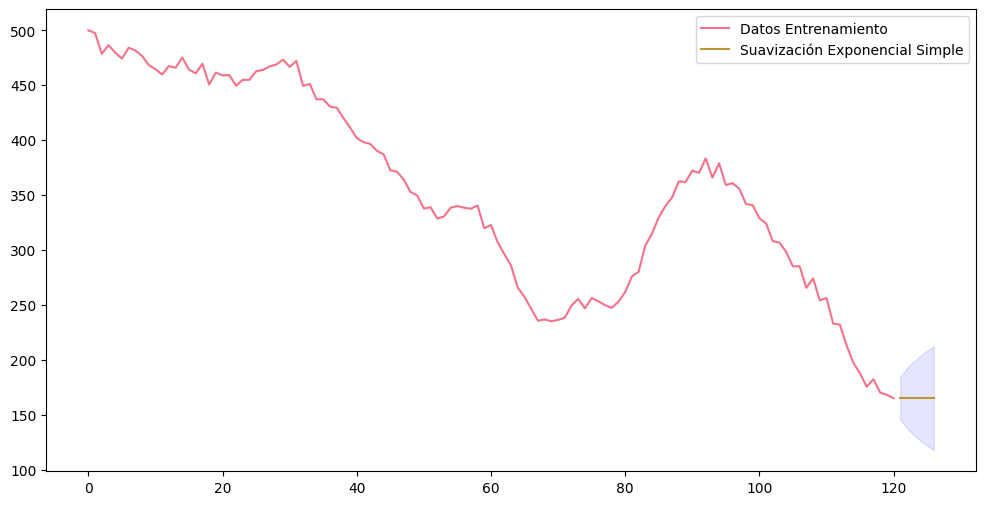

In [192]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to1,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend(loc= "upper right")
plt.show()

In [193]:
print(f"Alpha: {ets_result.alpha}") 
print(f"Beta: No hay beta porque no hay tendencia")
print(f"Gamma: No hay gama porque no hay estacionalidad")

Alpha: 0.9999
Beta: No hay beta porque no hay tendencia
Gamma: No hay gama porque no hay estacionalidad


In [194]:
rmse = np.sqrt(mean_squared_error(test_to1,point_forecast ))
print(f"RMSE: {rmse}")

RMSE: 16.974646708474932


Suavización exponencial lineal

In [195]:
# Build model.
ets_model = ETSModel(endog=train_to1["producto1"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

     Point_forecast    lower_95    upper_95
121      162.547388  153.960763  169.859194
122      159.544291  148.250405  170.649682
123      156.596677  140.673338  173.524540
124      153.703521  132.981463  177.713559
125      150.863816  124.037257  182.976342
126      148.076576  114.515147  190.102456



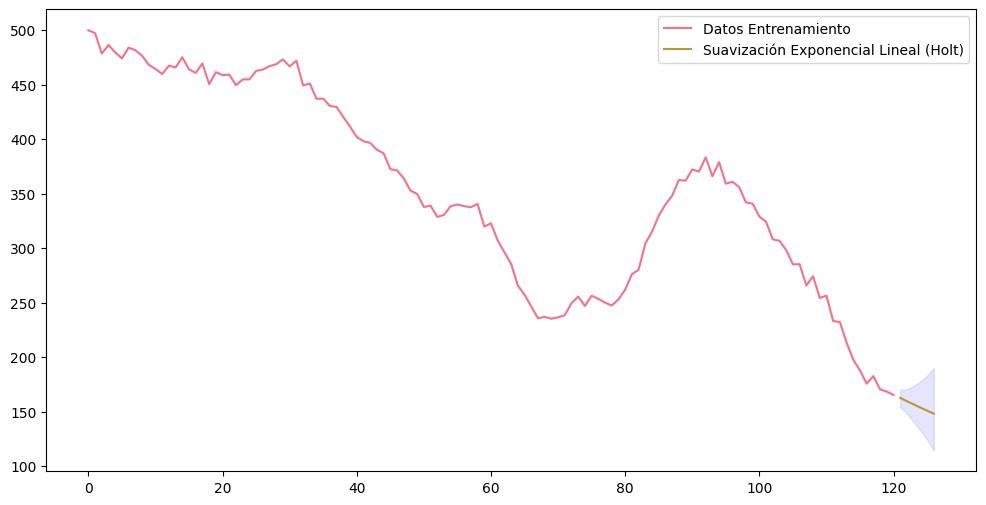

In [196]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to1["producto1"] ,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend(loc= "upper right")
plt.show()

In [197]:
print(f"Alpha: {ets_result.alpha}") 
print(f"Beta: {ets_result.beta}")
print(f"Gamma: No hay gama porque no hay estacionalidad")

Alpha: 0.5357141588057284
Beta: 0.5356605873898478
Gamma: No hay gama porque no hay estacionalidad


In [198]:
rmse_holt = np.sqrt(mean_squared_error(test_to1,preds_holt['Point_forecast']))
print(f"RMSE: {rmse_holt}")

RMSE: 7.002820498650496


Suavización exponencial lineal de Winters

In [199]:
# Build model with seasonal periods specification
ets_model = ETSModel(endog=train_to1["producto1"], error="add", trend="add", seasonal="add", seasonal_periods=6)
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

     Point_forecast    lower_95    upper_95
121      165.769926  150.517767  181.022084
122      161.629284  139.687257  183.571311
123      158.659244  126.390244  190.928245
124      155.151453  110.023462  200.279443
125      151.323044   91.393138  211.252950
126      150.138184   73.778100  226.498267


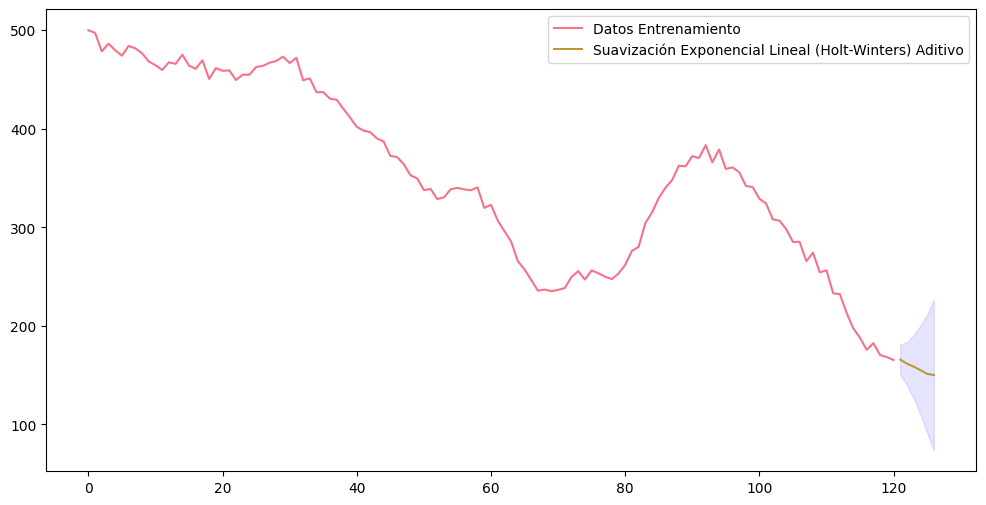

In [200]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to1,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend(loc= "upper right")
plt.show()

In [201]:
print(f"Alpha: {ets_result.alpha}") 
print(f"Beta: {ets_result.beta}")
print(f"Gamma: {ets_result.gamma}")

Alpha: 0.5171383546282352
Beta: 0.5170866407927724
Gamma: 4.8286164537176484e-05


In [202]:
rmse_hw_add = np.sqrt(mean_squared_error(test_to1,preds_hw_add['Point_forecast']))
print(f"RMSE: {rmse_hw_add}")

RMSE: 7.661185573001553


Optimización Bayesiana

In [216]:
def evaluar_rolling_forecast_holtwinters(serie, alpha, beta, gamma, seasonal='add', trend='add',
                                          window_size=60, window=12, step_size=1, 
                                          horizon=6, metric='rmse'):
    """
    Evalúa el rendimiento de un modelo Holt-Winters usando validación cruzada con ventana móvil.
    
    La función simula el proceso de pronóstico en tiempo real, donde en cada iteración:
    1. Se usa una ventana fija de datos históricos para entrenar
    2. Se predice un horizonte fijo hacia el futuro
    3. Se comparan las predicciones con los valores reales observados
    4. La ventana se "desliza" al siguiente período

    Parámetros:
        serie       : Serie temporal de datos históricos
        alpha       : Suavización del nivel (0-1). Controla qué tan rápido se adapta a cambios
        beta        : Suavización de tendencia (0-1). Controla sensibilidad a cambios de pendiente
        gamma       : Suavización estacional (0-1). Controla adaptación a patrones estacionales
        seasonal    : Tipo de estacionalidad ('add' aditiva, 'mul' multiplicativa)
        window_size : Tamaño fijo de la ventana móvil para entrenamiento
        window      : Número de pronósticos a evaluar (desde el final hacia atrás)
        step_size   : Cada cuántos puntos avanza la ventana (1 = cada mes)
        horizon     : Cuántos períodos hacia adelante predecir en cada iteración
        metric      : Métrica de error ('rmse' o 'mae')

    Retorna:
        float: Error promedio entre todas las predicciones vs valores reales observados
    """
    
    # Preparación inicial: limpiar datos y definir puntos de evaluación
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos, observados = [], []
    
    # Definir dónde termina cada ventana de entrenamiento (desde el final hacia atrás)
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    for i, end_train in enumerate(puntos_finales):
        # 1. Definir ventana móvil: siempre del mismo tamaño
        start_train = max(0, end_train - window_size)
        train = serie.iloc[start_train:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        # 2. Validaciones básicas: datos suficientes y sin valores faltantes
        if len(test) < horizon or len(train) < 24 or test.isna().any() or train.isna().any():
            continue
            
        try:
            # 3. Entrenar modelo Holt-Winters con parámetros específicos
            model = ExponentialSmoothing(
                train, trend=trend, seasonal=seasonal, 
                seasonal_periods=6, initialization_method='estimated'
            ).fit(smoothing_level=alpha, smoothing_trend=beta, 
                  smoothing_seasonal=gamma, optimized=False)
            
            # 4. Generar pronósticos para el horizonte definido
            pred = pd.Series(model.forecast(steps=horizon)).astype(float)
            
            # 5. Filtrar predicciones válidas y acumular resultados
            mask = (~pred.isna()) & (~test.isna())
            if mask.sum() > 0:
                predichos.extend(pred[mask].tolist())
                observados.extend(test[mask].tolist())
                
        except Exception as e:
            # Continuar con la siguiente iteración si hay errores en el ajuste
            continue
    
    # Cálculo final del error promedio
    if len(predichos) == 0:
        return np.inf
        
    predichos, observados = np.array(predichos), np.array(observados)
    mask_finite = np.isfinite(predichos) & np.isfinite(observados)
    
    if mask_finite.sum() == 0:
        return np.inf
        
    predichos_clean = predichos[mask_finite]
    observados_clean = observados[mask_finite]
    
    # Retornar métrica solicitada
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados_clean, predichos_clean))
    elif metric == 'mae':
        return np.mean(np.abs(observados_clean - predichos_clean))
    else:
        raise ValueError("Metrica debe ser 'rmse' o 'mae'")

In [ ]:
# Optimización con VENTANA MÓVIL para Holt-Winters
warnings.filterwarnings("ignore")

def evaluar_hw_ventana_movil(train, test, alpha, beta, gamma, seasonal, trend):
    """
    Evaluación de Holt-Winters con ventana móvil (walking forward)
    Predice 1 paso adelante, incorpora valor real, y repite
    """
    try:
        predicciones = []
        datos_disponibles = train.copy()
        
        # Walking forward: predecir 1 paso adelante para cada período de test
        for i in range(len(test)):
            # Configurar modelo según parámetros con datos disponibles hasta ahora
            if seasonal is None and trend is None:
                # Solo nivel (suavización exponencial simple)
                model = ExponentialSmoothing(datos_disponibles, trend=None, seasonal=None)
                fitted = model.fit(smoothing_level=alpha, optimized=False)
            elif seasonal is None:
                # Con tendencia pero sin estacionalidad
                model = ExponentialSmoothing(datos_disponibles, trend=trend, seasonal=None)
                fitted = model.fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)
            elif trend is None:
                # Con estacionalidad pero sin tendencia
                seasonal_periods = min(6, len(datos_disponibles)//2)
                model = ExponentialSmoothing(datos_disponibles, trend=None, seasonal=seasonal, 
                                            seasonal_periods=seasonal_periods)
                fitted = model.fit(smoothing_level=alpha, smoothing_seasonal=gamma, optimized=False)
            else:
                # Con tendencia y estacionalidad
                seasonal_periods = min(6, len(datos_disponibles)//2)
                model = ExponentialSmoothing(datos_disponibles, trend=trend, seasonal=seasonal, 
                                            seasonal_periods=seasonal_periods)
                fitted = model.fit(smoothing_level=alpha, smoothing_trend=beta, 
                                 smoothing_seasonal=gamma, optimized=False)
            
            # Predecir SOLO el siguiente período (1 paso adelante)
            prediccion = fitted.forecast(steps=1).iloc[0]
            
            if not np.isfinite(prediccion):
                return np.inf
            
            predicciones.append(prediccion)
            
            # Incorporar el valor REAL del test para la siguiente iteración
            valor_real = test.iloc[i]
            nuevo_indice = datos_disponibles.index[-1] + 1
            datos_disponibles.loc[nuevo_indice] = valor_real
        
        # Calcular RMSE con todas las predicciones
        rmse = np.sqrt(mean_squared_error(test, predicciones))
        return rmse
        
    except Exception as e:
        return np.inf


def objective_holtwinters(trial):
    """Función objetivo para optimización de Holt-Winters con ventana móvil"""
    # Parámetros de suavización
    alpha = trial.suggest_float("alpha", 0.01, 0.99)
    
    # Tipo de modelo (None es el objeto Python, no string)
    seasonal = trial.suggest_categorical("seasonal", ["add","mul", None])
    trend = trial.suggest_categorical("trend", ["add", "mul", None])
    
    # Parámetros condicionales
    beta = trial.suggest_float("beta", 0.01, 0.99) if trend is not None else None
    gamma = trial.suggest_float("gamma", 0.01, 0.99) if seasonal is not None else None
    
    return evaluar_hw_ventana_movil(
        train_to1["producto1"], 
        test_to1["producto1"],
        alpha, beta, gamma, seasonal, trend
    )



study_hw = optuna.create_study(direction="minimize")
study_hw.optimize(objective_holtwinters, n_trials=1000)



[I 2025-12-05 21:44:06,980] A new study created in memory with name: no-name-dccc43b8-1dd1-4157-aaf2-b69f1c703dea
[I 2025-12-05 21:44:07,034] Trial 0 finished with value: 10.86838968707134 and parameters: {'alpha': 0.18926111515512545, 'seasonal': 'mul', 'trend': 'add', 'beta': 0.014170430189627797, 'gamma': 0.21323396069218215}. Best is trial 0 with value: 10.86838968707134.
[I 2025-12-05 21:44:07,034] Trial 0 finished with value: 10.86838968707134 and parameters: {'alpha': 0.18926111515512545, 'seasonal': 'mul', 'trend': 'add', 'beta': 0.014170430189627797, 'gamma': 0.21323396069218215}. Best is trial 0 with value: 10.86838968707134.
[I 2025-12-05 21:44:07,065] Trial 1 finished with value: 9.02900431816058 and parameters: {'alpha': 0.34522284949564724, 'seasonal': None, 'trend': 'add', 'beta': 0.07796660472663482}. Best is trial 1 with value: 9.02900431816058.
[I 2025-12-05 21:44:07,104] Trial 2 finished with value: 367.39740428526744 and parameters: {'alpha': 0.5313215220561796, 'se

Iniciando optimización Holt-Winters con VENTANA MÓVIL
Predicción 1 paso adelante, incorporando valores reales
------------------------------------------------------------


[I 2025-12-05 21:44:07,299] Trial 5 finished with value: 11.792021401239335 and parameters: {'alpha': 0.8336275415941437, 'seasonal': 'add', 'trend': 'add', 'beta': 0.36334668025298444, 'gamma': 0.4349547937455774}. Best is trial 1 with value: 9.02900431816058.
[I 2025-12-05 21:44:07,323] Trial 6 finished with value: 15.42200847838455 and parameters: {'alpha': 0.6227822540638683, 'seasonal': 'mul', 'trend': None, 'gamma': 0.9668819236023957}. Best is trial 1 with value: 9.02900431816058.
[I 2025-12-05 21:44:07,323] Trial 6 finished with value: 15.42200847838455 and parameters: {'alpha': 0.6227822540638683, 'seasonal': 'mul', 'trend': None, 'gamma': 0.9668819236023957}. Best is trial 1 with value: 9.02900431816058.
[I 2025-12-05 21:44:07,440] Trial 7 finished with value: 14017.705928213549 and parameters: {'alpha': 0.6438145502167277, 'seasonal': 'mul', 'trend': 'add', 'beta': 0.7630746277028794, 'gamma': 0.7008545217419649}. Best is trial 1 with value: 9.02900431816058.
[I 2025-12-05 2


RESULTADOS OPTIMIZACIÓN - PRODUCTO 1
Mejor RMSE: 3.7346

Mejores parámetros:
  alpha: 0.1708
  seasonal: add
  trend: add
  beta: 0.0586
  gamma: 0.2253


In [236]:
study_hw.best_params

{'alpha': 0.17078967719225152,
 'seasonal': 'add',
 'trend': 'add',
 'beta': 0.05858052677404957,
 'gamma': 0.2252866044821772}

In [235]:
# Modelo final con mejores parámetros
best_params = study_hw.best_params
serie_completa = pd.Series(data["producto1"]).astype(float).dropna()

In [237]:
## Quemo las variables porque así quedó en el notebook, pero en realidad se pueden usar directamente best_params, 
# quitar el comentario para borrar y dejar el que viene del modelo
#"""
best_params = {'alpha': 0.17078967719225152,
 'seasonal': 'add',
 'trend': 'add',
 'beta': 0.05858052677404957,
 'gamma': 0.2252866044821772}
 
#"""

Generando predicciones con el mejor modelo...


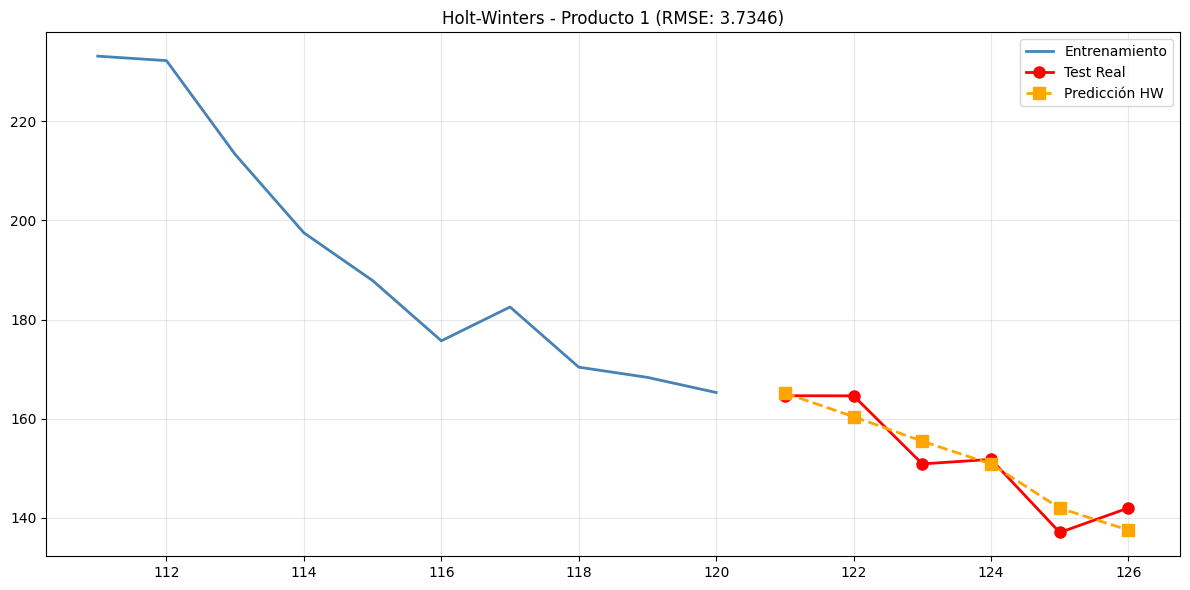


RMSE Holt-Winters: 3.7346
RMSE Media Móvil (ventana 2): 8.5543


In [239]:
# Visualización de predicciones vs valores reales - Holt-Winters con Ventana Móvil
print("Generando predicciones con el mejor modelo...")

# Obtener mejores parámetros
best_alpha = best_params['alpha']
best_beta = best_params.get('beta', None)
best_gamma = best_params.get('gamma', None)
best_seasonal = best_params.get('seasonal', None)
best_trend = best_params.get('trend', None)

# Generar predicciones con ventana móvil usando los mejores parámetros
predicciones_hw = []
datos_disponibles = train_to1['producto1'].copy()

for i in range(len(test_to1)):
    # Configurar modelo según parámetros
    if best_seasonal is None and best_trend is None:
        model = ExponentialSmoothing(datos_disponibles, trend=None, seasonal=None)
        fitted = model.fit(smoothing_level=best_alpha, optimized=False)
    elif best_seasonal is None:
        model = ExponentialSmoothing(datos_disponibles, trend=best_trend, seasonal=None)
        fitted = model.fit(smoothing_level=best_alpha, smoothing_trend=best_beta, optimized=False)
    elif best_trend is None:
        seasonal_periods = min(6, len(datos_disponibles)//2)
        model = ExponentialSmoothing(datos_disponibles, trend=None, seasonal=best_seasonal, 
                                    seasonal_periods=seasonal_periods)
        fitted = model.fit(smoothing_level=best_alpha, smoothing_seasonal=best_gamma, optimized=False)
    else:
        seasonal_periods = min(6, len(datos_disponibles)//2)
        model = ExponentialSmoothing(datos_disponibles, trend=best_trend, seasonal=best_seasonal, 
                                    seasonal_periods=seasonal_periods)
        fitted = model.fit(smoothing_level=best_alpha, smoothing_trend=best_beta, 
                         smoothing_seasonal=best_gamma, optimized=False)
    
    # Predecir siguiente período
    prediccion = fitted.forecast(steps=1).iloc[0]
    predicciones_hw.append(prediccion)
    
    # Incorporar valor real
    valor_real = test_to1['producto1'].iloc[i]
    nuevo_indice = datos_disponibles.index[-1] + 1
    datos_disponibles.loc[nuevo_indice] = valor_real

# Calcular RMSE
rmse_hw = np.sqrt(mean_squared_error(test_to1['producto1'], predicciones_hw))

# Gráfico simple enfocado en test
fig = plt.figure(figsize=(12, 6))

# Mostrar solo últimos 10 períodos de entrenamiento + test
ultimos_train = train_to1['producto1'].iloc[-10:]

plt.plot(ultimos_train.index, ultimos_train.values, 
         label='Entrenamiento', color='steelblue', linewidth=2)

plt.plot(test_to1.index, test_to1['producto1'], 
         label='Test Real', color='red', linewidth=2, marker='o', markersize=8)

plt.plot(test_to1.index, predicciones_hw, 
         label=f'Predicción HW', color='orange', linewidth=2, 
         marker='s', markersize=8, linestyle='--')

plt.title(f'Holt-Winters - Producto 1 (RMSE: {rmse_hw:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRMSE Holt-Winters: {rmse_hw:.4f}")
print(f"RMSE Media Móvil (ventana {mejor_ventana}): {resultados_rmse[mejor_ventana]['rmse']:.4f}")

## 6. MEDIA MÓVIL - PRODUCTO 2

In [241]:
## Considerando el dato actual. Números 2,3,4,5 ventanas (datos del más cercano al más lejano para predecir)
ma_2_p2 = train_to2.rolling(2,min_periods=2).mean()
ma_3_p2 = train_to2.rolling(3,min_periods=2).mean()
ma_4_p2 = train_to2.rolling(4,min_periods=2).mean()
ma_5_p2 = train_to2.rolling(5,min_periods=2).mean()
ma_6_p2 = train_to2.rolling(6,min_periods=2).mean()

In [242]:
## Sin considerar el dato actual, por si el periodo no ha finalizado. Preguntar ¿Cuándo debe correr el modelo?
ma_2_p2 = train_to2.shift().rolling(2,min_periods=2).mean()
ma_3_p2 = train_to2.shift().rolling(3,min_periods=2).mean()
ma_4_p2 = train_to2.shift().rolling(4,min_periods=2).mean()
ma_5_p2 = train_to2.shift().rolling(5,min_periods=2).mean()
ma_6_p2 = train_to2.shift().rolling(6,min_periods=2).mean()

In [243]:
# Pronósticos con fore_ma_simple para Producto 2
ma_2_f_p2 = fore_ma_simple(train_to2['producto2'], 2, 1)
ma_3_f_p2 = fore_ma_simple(train_to2['producto2'], 3, 1) 
ma_4_f_p2 = fore_ma_simple(train_to2['producto2'], 4, 1)
ma_5_f_p2 = fore_ma_simple(train_to2['producto2'], 5, 1)
ma_6_f_p2 = fore_ma_simple(train_to2['producto2'], 6, 1)

print("Pronósticos de Media Móvil para Producto 2:")
print(f"MA(2): {ma_2_f_p2.iloc[0]:.4f}")
print(f"MA(3): {ma_3_f_p2.iloc[0]:.4f}")
print(f"MA(4): {ma_4_f_p2.iloc[0]:.4f}")
print(f"MA(5): {ma_5_f_p2.iloc[0]:.4f}")
print(f"MA(6): {ma_6_f_p2.iloc[0]:.4f}")

Pronósticos de Media Móvil para Producto 2:
MA(2): 607.9572
MA(3): 605.6369
MA(4): 603.7092
MA(5): 605.3673
MA(6): 608.6057


In [244]:
# Seleccionar métrica más baja comparando solo el primer período de prueba - Producto 2
primer_valor_real_p2 = test_to2['producto2'].iloc[0]

rmse_ma_2_p2 = abs(primer_valor_real_p2 - ma_2_f_p2.iloc[0])
rmse_ma_3_p2 = abs(primer_valor_real_p2 - ma_3_f_p2.iloc[0])
rmse_ma_4_p2 = abs(primer_valor_real_p2 - ma_4_f_p2.iloc[0])
rmse_ma_5_p2 = abs(primer_valor_real_p2 - ma_5_f_p2.iloc[0])
rmse_ma_6_p2 = abs(primer_valor_real_p2 - ma_6_f_p2.iloc[0])

print("Errores absolutos para un período adelante:")
print(f"RMSE MA(2): {rmse_ma_2_p2:.4f}")
print(f"RMSE MA(3): {rmse_ma_3_p2:.4f}")
print(f"RMSE MA(4): {rmse_ma_4_p2:.4f}")
print(f"RMSE MA(5): {rmse_ma_5_p2:.4f}")
print(f"RMSE MA(6): {rmse_ma_6_p2:.4f}")

# Encontrar la mejor ventana
errores_p2 = [rmse_ma_2_p2, rmse_ma_3_p2, rmse_ma_4_p2, rmse_ma_5_p2, rmse_ma_6_p2]
ventanas_nombres_p2 = ['MA(2)', 'MA(3)', 'MA(4)', 'MA(5)', 'MA(6)']
mejor_ventana_simple_p2 = ventanas_nombres_p2[errores_p2.index(min(errores_p2))]
print(f"\nMejor método: {mejor_ventana_simple_p2} con error absoluto: {min(errores_p2):.4f}")

Errores absolutos para un período adelante:
RMSE MA(2): 16.5449
RMSE MA(3): 18.8652
RMSE MA(4): 20.7929
RMSE MA(5): 19.1348
RMSE MA(6): 15.8964

Mejor método: MA(6) con error absoluto: 15.8964


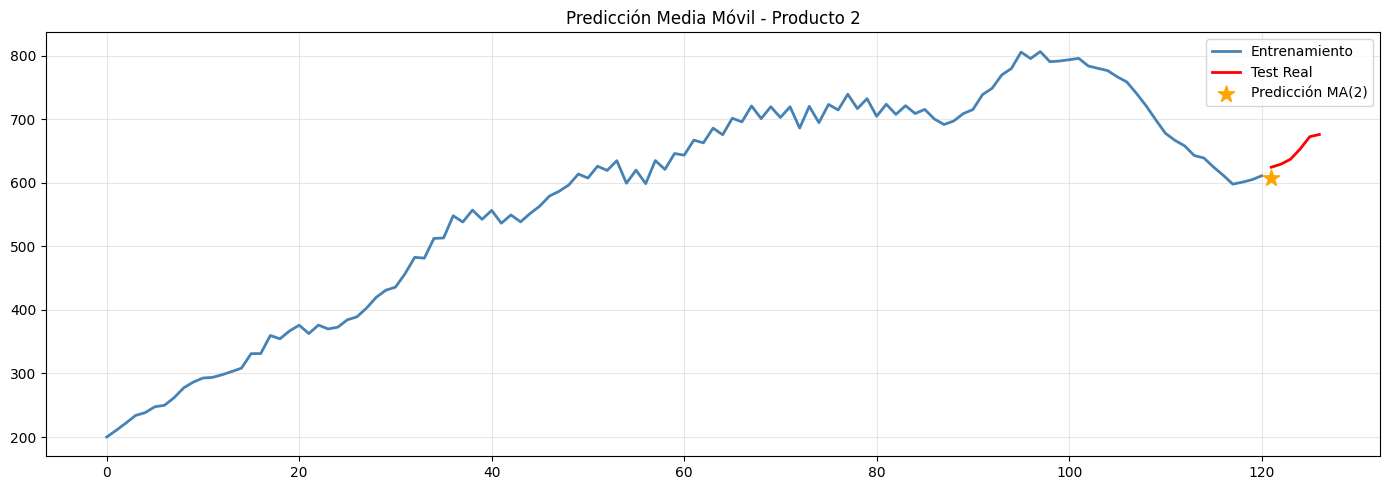

In [246]:
# Visualización simple de predicción MA - Producto 2
fig = plt.figure(figsize=(14, 5))

plt.plot(train_to2.index, train_to2['producto2'], label="Entrenamiento", 
         color='steelblue', linewidth=2)
plt.plot(test_to2.index, test_to2['producto2'], label="Test Real", 
         color='red', linewidth=2)
plt.scatter([test_to2.index[0]], [ma_2_f_p2.iloc[0]], 
            label="Predicción MA(2)", color='orange', s=150, marker='*', zorder=5)

plt.title('Predicción Media Móvil - Producto 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [247]:
# Evaluación con ventana móvil (walking forward) para cada ventana - PRODUCTO 2
print("EVALUACIÓN CON VENTANA MÓVIL - PRODUCTO 2")
print("=" * 60)

ventanas_evaluar_p2 = [2, 3, 4, 5, 6]
resultados_rmse_p2 = {}

for w in ventanas_evaluar_p2:
    predicciones_test = []
    valores_reales = []
    
    # Walking forward sobre el conjunto de test
    for i in range(len(test_to2)):
        # Obtener todos los datos disponibles hasta este punto (train + test ya observados)
        if i == 0:
            datos_disponibles = train_to2['producto2'].copy()
        else:
            datos_disponibles = pd.concat([train_to2['producto2'], test_to2['producto2'].iloc[:i]])
        
        # Predecir usando los últimos w datos
        prediccion = datos_disponibles.iloc[-w:].mean()
        valor_real = test_to2['producto2'].iloc[i]
        
        predicciones_test.append(prediccion)
        valores_reales.append(valor_real)
    
    # Calcular RMSE para esta ventana
    rmse = np.sqrt(mean_squared_error(valores_reales, predicciones_test))
    resultados_rmse_p2[w] = {
        'rmse': rmse,
        'predicciones': predicciones_test,
        'reales': valores_reales
    }
    
    print(f"Ventana MA({w}): RMSE = {rmse:.4f}")

# Encontrar mejor ventana
mejor_ventana_p2 = min(resultados_rmse_p2.keys(), key=lambda x: resultados_rmse_p2[x]['rmse'])
print(f"\nMejor ventana: MA({mejor_ventana_p2}) con RMSE = {resultados_rmse_p2[mejor_ventana_p2]['rmse']:.4f}")
print("=" * 60)

EVALUACIÓN CON VENTANA MÓVIL - PRODUCTO 2
Ventana MA(2): RMSE = 17.4877
Ventana MA(3): RMSE = 22.0302
Ventana MA(4): RMSE = 26.0255
Ventana MA(5): RMSE = 29.3229
Ventana MA(6): RMSE = 31.9818

Mejor ventana: MA(2) con RMSE = 17.4877


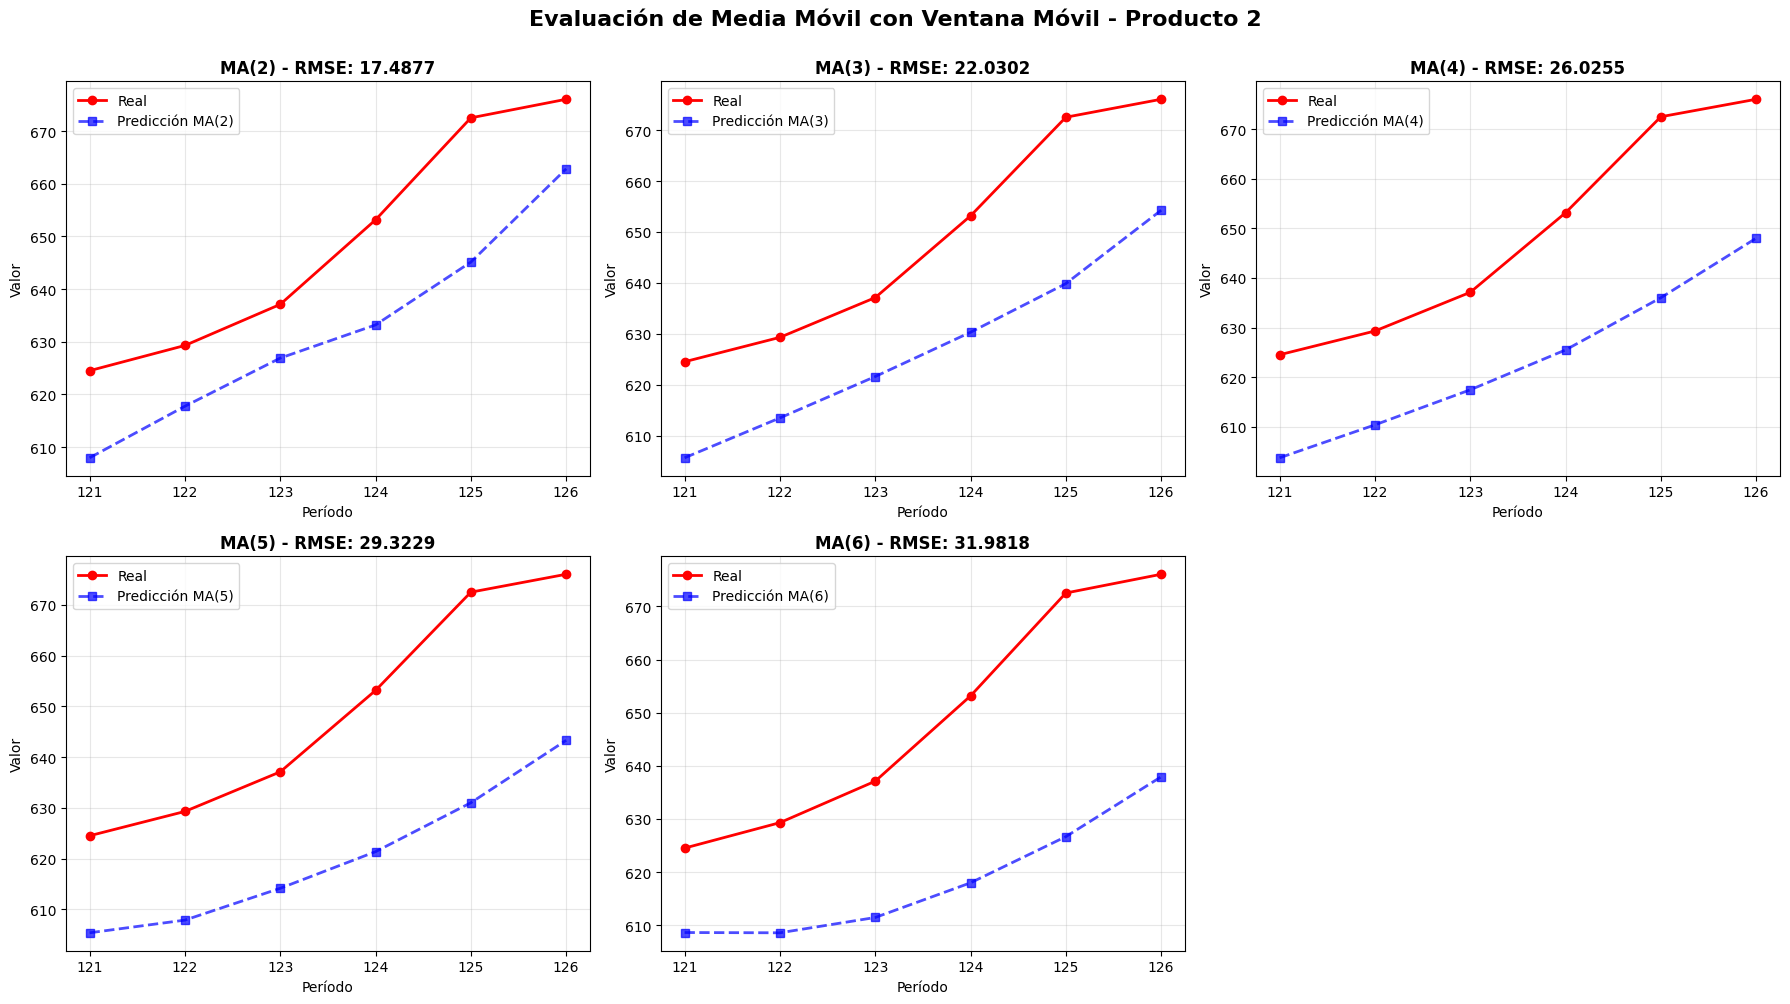

In [248]:
# Visualización de predicciones vs valores reales - Producto 2
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, w in enumerate(ventanas_evaluar_p2):
    ax = axes[idx]
    
    # Plotear valores reales y predicciones
    indices_test = test_to2.index
    ax.plot(indices_test, resultados_rmse_p2[w]['reales'], 
            label='Real', marker='o', linewidth=2, markersize=6, color='red')
    ax.plot(indices_test, resultados_rmse_p2[w]['predicciones'], 
            label=f'Predicción MA({w})', marker='s', linewidth=2, 
            markersize=6, linestyle='--', color='blue', alpha=0.7)
    
    ax.set_title(f'MA({w}) - RMSE: {resultados_rmse_p2[w]["rmse"]:.4f}', fontweight='bold')
    ax.set_xlabel('Período')
    ax.set_ylabel('Valor')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Ocultar subplot extra
axes[5].axis('off')

plt.suptitle('Evaluación de Media Móvil con Ventana Móvil - Producto 2', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. HOLT-WINTERS - PRODUCTO 2

Suavización exponencial simple

In [249]:
# Build model - Producto 2
ets_model_p2 = ETSModel(endog=train_to2["producto2"],error="add")
ets_result_p2 = ets_model_p2.fit()

point_forecast_p2=ets_result_p2.forecast(6)

ci_p2 = ets_result_p2.get_prediction(start = point_forecast_p2.index[0],
                                end = point_forecast_p2.index[-1])

conf_forecast_p2 = ci_p2.pred_int(alpha=0.05)
limits_p2 = ci_p2.predicted_mean

preds_p2 = pd.concat([limits_p2, conf_forecast_p2], axis = 1)
preds_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_p2)

     Point_forecast    lower_95    upper_95
121      610.228789  579.206355  641.251223
122      610.228789  568.847463  651.610115
123      610.228789  560.605843  659.851735
124      610.228789  553.550226  666.907352
125      610.228789  547.280539  673.177039
126      610.228789  541.581103  678.876475


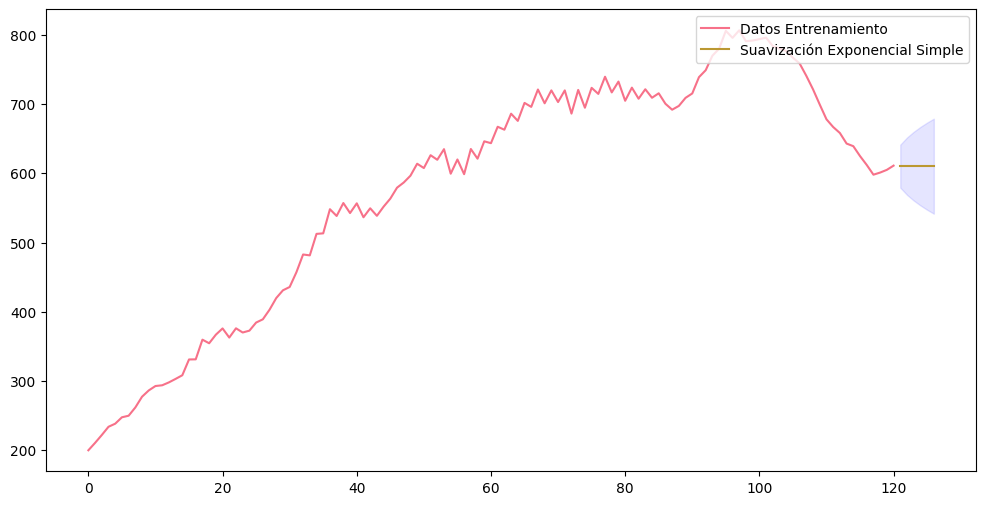

In [250]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to2,label="Datos Entrenamiento")
plt.plot(preds_p2['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds_p2.index ,preds_p2['lower_95'], preds_p2['upper_95'], color='blue', alpha=0.1)
plt.legend(loc= "upper right")
plt.show()

In [251]:
print(f"Alpha: {ets_result_p2.alpha}") 
print(f"Beta: No hay beta porque no hay tendencia")
print(f"Gamma: No hay gama porque no hay estacionalidad")

Alpha: 0.8827979683413618
Beta: No hay beta porque no hay tendencia
Gamma: No hay gama porque no hay estacionalidad


In [252]:
rmse_p2 = np.sqrt(mean_squared_error(test_to2,point_forecast_p2))
print(f"RMSE: {rmse_p2}")

RMSE: 43.48682141171178


Suavización exponencial lineal

In [253]:
# Build model - Producto 2
ets_model_p2 = ETSModel(endog=train_to2["producto2"],error="mul",trend="mul")
ets_result_p2 = ets_model_p2.fit()

point_forecast_p2=ets_result_p2.forecast(6)

ci_p2 = ets_result_p2.get_prediction(start = point_forecast_p2.index[0],
                                end = point_forecast_p2.index[-1])

conf_forecast_p2 = ci_p2.pred_int(alpha=0.05)
limits_p2 = ci_p2.predicted_mean

preds_holt_p2 = pd.concat([limits_p2, conf_forecast_p2], axis = 1)
preds_holt_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt_p2)

     Point_forecast    lower_95    upper_95
121      611.040443  582.035555  638.269792
122      616.720355  577.318097  658.877318
123      622.453065  567.130262  681.852915
124      628.239063  556.279384  713.027427
125      634.078845  540.949576  747.948333
126      639.972910  524.373282  785.328568


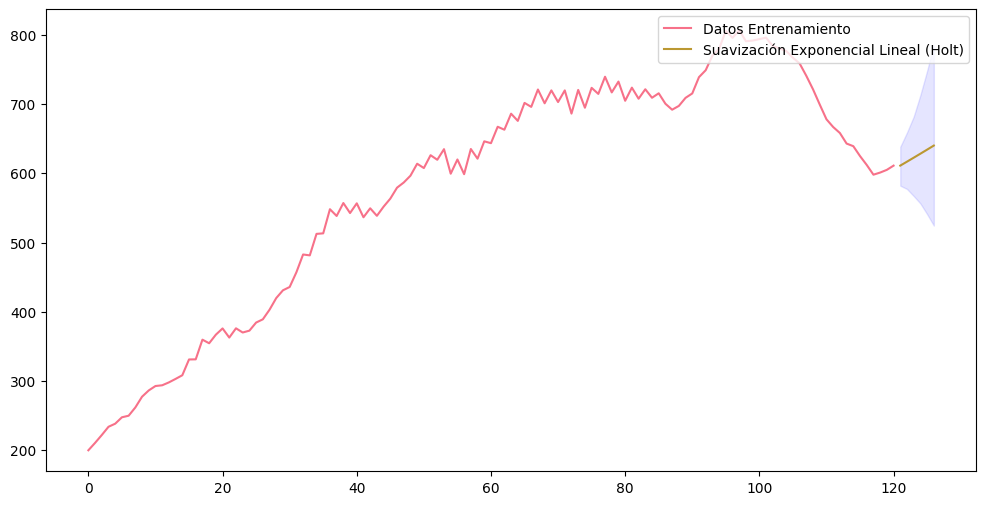

In [254]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to2["producto2"] ,label="Datos Entrenamiento")
plt.plot(preds_holt_p2['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt_p2.index ,preds_holt_p2['lower_95'], preds_holt_p2['upper_95'], color='blue', alpha=0.1)
plt.legend(loc= "upper right")
plt.show()

In [255]:
print(f"Alpha: {ets_result_p2.alpha}") 
print(f"Beta: {ets_result_p2.beta}")
print(f"Gamma: No hay gama porque no hay estacionalidad")

Alpha: 0.5765133396216445
Beta: 0.42197365988923907
Gamma: No hay gama porque no hay estacionalidad


In [256]:
rmse_holt_p2 = np.sqrt(mean_squared_error(test_to2,preds_holt_p2['Point_forecast']))
print(f"RMSE: {rmse_holt_p2}")

RMSE: 25.67465669046187


Suavización exponencial lineal de Winters

In [257]:
# Build model with seasonal periods specification - Producto 2
ets_model_p2 = ETSModel(endog=train_to2["producto2"], error="add", trend="add", seasonal="add", seasonal_periods=6)
ets_result_p2 = ets_model_p2.fit()

point_forecast_p2=ets_result_p2.forecast(6)

ci_p2 = ets_result_p2.get_prediction(start = point_forecast_p2.index[0],
                                end = point_forecast_p2.index[-1])

conf_forecast_p2 = ci_p2.pred_int(alpha=0.05)
limits_p2 = ci_p2.predicted_mean

preds_hw_add_p2 = pd.concat([limits_p2, conf_forecast_p2], axis = 1)
preds_hw_add_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add_p2)

     Point_forecast    lower_95    upper_95
121      611.461943  587.305212  635.618674
122      616.222484  580.045806  652.399162
123      622.526981  568.301457  676.752505
124      637.624002  561.197044  714.050959
125      644.078755  542.229184  745.928326
126      650.465825  520.466828  780.464821


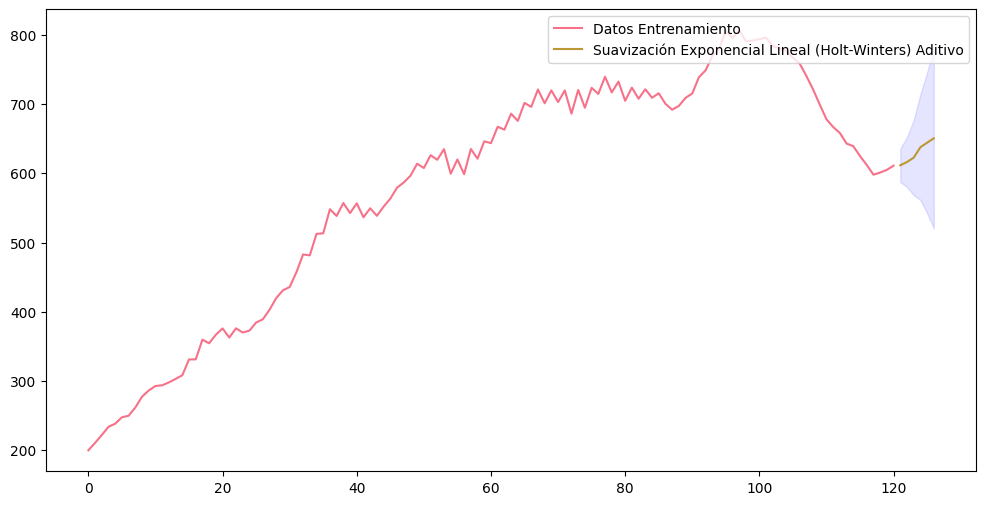

In [258]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to2,label="Datos Entrenamiento")
plt.plot(preds_hw_add_p2['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add_p2.index ,preds_hw_add_p2['lower_95'], preds_hw_add_p2['upper_95'], color='blue', alpha=0.1)
plt.legend(loc= "upper right")
plt.show()

In [259]:
print(f"Alpha: {ets_result_p2.alpha}") 
print(f"Beta: {ets_result_p2.beta}")
print(f"Gamma: {ets_result_p2.gamma}")

Alpha: 0.5574215438655049
Beta: 0.5573658017111184
Gamma: 0.4189021350292265


In [260]:
rmse_hw_add_p2 = np.sqrt(mean_squared_error(test_to2,preds_hw_add_p2['Point_forecast']))
print(f"RMSE: {rmse_hw_add_p2}")

RMSE: 19.40277632564384


Optimización Bayesiana

In [263]:
# Optimización con VENTANA MÓVIL para Holt-Winters - PRODUCTO 2
warnings.filterwarnings("ignore")

def objective_holtwinters_p2(trial):
    """Función objetivo para optimización de Holt-Winters con ventana móvil - Producto 2"""
    # Parámetros de suavización
    alpha = trial.suggest_float("alpha", 0.01, 0.99)
    
    # Tipo de modelo (None es el objeto Python, no string)
    seasonal = trial.suggest_categorical("seasonal", ["add","mul", None])
    trend = trial.suggest_categorical("trend", ["add", "mul", None])
    
    # Parámetros condicionales
    beta = trial.suggest_float("beta", 0.01, 0.99) if trend is not None else None
    gamma = trial.suggest_float("gamma", 0.01, 0.99) if seasonal is not None else None
    
    return evaluar_hw_ventana_movil(
        train_to2["producto2"], 
        test_to2["producto2"],
        alpha, beta, gamma, seasonal, trend
    )


study_hw_p2 = optuna.create_study(direction="minimize")
study_hw_p2.optimize(objective_holtwinters_p2, n_trials=1000)



[I 2025-12-05 22:06:44,680] A new study created in memory with name: no-name-4137437c-c62e-430d-9aa8-2c71cb0b28c9
[I 2025-12-05 22:06:44,730] Trial 0 finished with value: 145.41054255135236 and parameters: {'alpha': 0.849166921599922, 'seasonal': 'add', 'trend': 'add', 'beta': 0.6367323873010439, 'gamma': 0.49773783174809605}. Best is trial 0 with value: 145.41054255135236.
[I 2025-12-05 22:06:44,751] Trial 1 finished with value: 12.996493894622375 and parameters: {'alpha': 0.8635903917256166, 'seasonal': 'mul', 'trend': None, 'gamma': 0.2778914442588052}. Best is trial 1 with value: 12.996493894622375.
[I 2025-12-05 22:06:44,730] Trial 0 finished with value: 145.41054255135236 and parameters: {'alpha': 0.849166921599922, 'seasonal': 'add', 'trend': 'add', 'beta': 0.6367323873010439, 'gamma': 0.49773783174809605}. Best is trial 0 with value: 145.41054255135236.
[I 2025-12-05 22:06:44,751] Trial 1 finished with value: 12.996493894622375 and parameters: {'alpha': 0.8635903917256166, 'sea

In [264]:
study_hw_p2.best_params

{'alpha': 0.5854123559959866,
 'seasonal': 'add',
 'trend': 'add',
 'beta': 0.9896418008960194,
 'gamma': 0.16844624433973068}

In [265]:
# Modelo final con mejores parámetros - Producto 2
best_params_p2 = study_hw_p2.best_params

In [267]:
## Quemo las variables porque así quedó en el notebook, pero en realidad se pueden usar directamente best_params, 
# quitar el comentario para borrar y dejar el que viene del modelo
#"""
best_params_p2 = {'alpha': 0.5854123559959866,
 'seasonal': 'add',
 'trend': 'add',
 'beta': 0.9896418008960194,
 'gamma': 0.16844624433973068}
 
#"""

Generando predicciones con el mejor modelo - Producto 2...


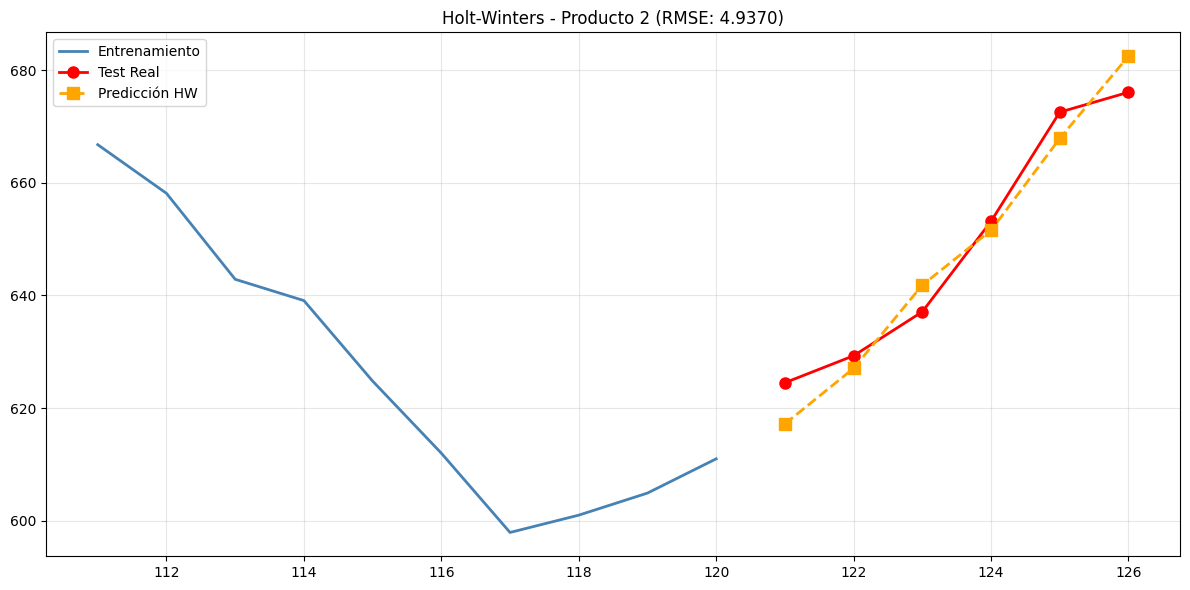


RMSE Holt-Winters: 4.9370
RMSE Media Móvil (ventana 2): 17.4877


In [268]:
# Visualización de predicciones vs valores reales - Holt-Winters Producto 2
print("Generando predicciones con el mejor modelo - Producto 2...")

# Obtener mejores parámetros
best_alpha_p2 = best_params_p2['alpha']
best_beta_p2 = best_params_p2.get('beta', None)
best_gamma_p2 = best_params_p2.get('gamma', None)
best_seasonal_p2 = best_params_p2.get('seasonal', None)
best_trend_p2 = best_params_p2.get('trend', None)

# Generar predicciones con ventana móvil usando los mejores parámetros
predicciones_hw_p2 = []
datos_disponibles_p2 = train_to2['producto2'].copy()

for i in range(len(test_to2)):
    # Configurar modelo según parámetros
    if best_seasonal_p2 is None and best_trend_p2 is None:
        model = ExponentialSmoothing(datos_disponibles_p2, trend=None, seasonal=None)
        fitted = model.fit(smoothing_level=best_alpha_p2, optimized=False)
    elif best_seasonal_p2 is None:
        model = ExponentialSmoothing(datos_disponibles_p2, trend=best_trend_p2, seasonal=None)
        fitted = model.fit(smoothing_level=best_alpha_p2, smoothing_trend=best_beta_p2, optimized=False)
    elif best_trend_p2 is None:
        seasonal_periods = min(6, len(datos_disponibles_p2)//2)
        model = ExponentialSmoothing(datos_disponibles_p2, trend=None, seasonal=best_seasonal_p2, 
                                    seasonal_periods=seasonal_periods)
        fitted = model.fit(smoothing_level=best_alpha_p2, smoothing_seasonal=best_gamma_p2, optimized=False)
    else:
        seasonal_periods = min(6, len(datos_disponibles_p2)//2)
        model = ExponentialSmoothing(datos_disponibles_p2, trend=best_trend_p2, seasonal=best_seasonal_p2, 
                                    seasonal_periods=seasonal_periods)
        fitted = model.fit(smoothing_level=best_alpha_p2, smoothing_trend=best_beta_p2, 
                         smoothing_seasonal=best_gamma_p2, optimized=False)
    
    # Predecir siguiente período
    prediccion = fitted.forecast(steps=1).iloc[0]
    predicciones_hw_p2.append(prediccion)
    
    # Incorporar valor real
    valor_real = test_to2['producto2'].iloc[i]
    nuevo_indice = datos_disponibles_p2.index[-1] + 1
    datos_disponibles_p2.loc[nuevo_indice] = valor_real

# Calcular RMSE
rmse_hw_p2 = np.sqrt(mean_squared_error(test_to2['producto2'], predicciones_hw_p2))

# Gráfico simple enfocado en test
fig = plt.figure(figsize=(12, 6))

# Mostrar solo últimos 10 períodos de entrenamiento + test
ultimos_train_p2 = train_to2['producto2'].iloc[-10:]

plt.plot(ultimos_train_p2.index, ultimos_train_p2.values, 
         label='Entrenamiento', color='steelblue', linewidth=2)

plt.plot(test_to2.index, test_to2['producto2'], 
         label='Test Real', color='red', linewidth=2, marker='o', markersize=8)

plt.plot(test_to2.index, predicciones_hw_p2, 
         label=f'Predicción HW', color='orange', linewidth=2, 
         marker='s', markersize=8, linestyle='--')

plt.title(f'Holt-Winters - Producto 2 (RMSE: {rmse_hw_p2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRMSE Holt-Winters: {rmse_hw_p2:.4f}")
print(f"RMSE Media Móvil (ventana {mejor_ventana_p2}): {resultados_rmse_p2[mejor_ventana_p2]['rmse']:.4f}")

## 8. RESUMEN COMPARATIVO

In [275]:
print("\n" + "="*80)
print("RESUMEN COMPARATIVO: MEDIA MÓVIL vs HOLT-WINTERS")
print("="*80 + "\n")

# Calcular métricas finales
mejor_p1 = 'Media Móvil' if resultados_rmse[mejor_ventana]['rmse'] < study_hw.best_value else 'Holt-Winters'
mejor_p2 = 'Media Móvil' if resultados_rmse_p2[mejor_ventana_p2]['rmse'] < study_hw_p2.best_value else 'Holt-Winters'

rmse_ma_p1 = resultados_rmse[mejor_ventana]['rmse']
rmse_hw_p1 = study_hw.best_value
rmse_ma_p2 = resultados_rmse_p2[mejor_ventana_p2]['rmse']
rmse_hw_p2 = study_hw_p2.best_value

# Tabla comparativa
print("COMPARACIÓN DE ERRORES (RMSE)")
print("-"*80)
tabla_comparativa = pd.DataFrame({
    'Modelo': [f'Media Móvil (MA-{mejor_ventana})', 'Holt-Winters'],
    'Producto 1': [rmse_ma_p1, rmse_hw_p1],
    'Producto 2': [rmse_ma_p2, rmse_hw_p2]
})
print(tabla_comparativa.to_string(index=False))

# Mejores modelos
print(f"\n\nMODELOS CON MEJOR DESEMPEÑO")
print("-"*80)
print(f"Producto 1: {mejor_p1} (RMSE = {min(rmse_ma_p1, rmse_hw_p1):.4f})")
print(f"Producto 2: {mejor_p2} (RMSE = {min(rmse_ma_p2, rmse_hw_p2):.4f})")

# Preparar modelos finales para predicciones futuras
# Entrenar modelos con todos los datos disponibles (train + test) para predicciones futuras

# Modelo Media Móvil - Producto 1
datos_completos_p1 = pd.concat([train_to1['producto1'], test_to1['producto1']])
modelo_ma_p1 = {
    'tipo': 'media_movil',
    'ventana': mejor_ventana,
    'datos_historicos': datos_completos_p1,  # Últimos datos para continuar prediciendo
    'rmse': rmse_ma_p1
}

# Modelo Media Móvil - Producto 2
datos_completos_p2 = pd.concat([train_to2['producto2'], test_to2['producto2']])
modelo_ma_p2 = {
    'tipo': 'media_movil',
    'ventana': mejor_ventana_p2,
    'datos_historicos': datos_completos_p2,
    'rmse': rmse_ma_p2
}

# Modelo Holt-Winters - Producto 1
# Entrenar con todos los datos para futuras predicciones
if best_seasonal is None and best_trend is None:
    modelo_hw_final_p1 = ExponentialSmoothing(datos_completos_p1, trend=None, seasonal=None)
    fitted_hw_p1 = modelo_hw_final_p1.fit(smoothing_level=best_alpha, optimized=False)
elif best_seasonal is None:
    modelo_hw_final_p1 = ExponentialSmoothing(datos_completos_p1, trend=best_trend, seasonal=None)
    fitted_hw_p1 = modelo_hw_final_p1.fit(smoothing_level=best_alpha, smoothing_trend=best_beta, optimized=False)
elif best_trend is None:
    seasonal_periods = min(6, len(datos_completos_p1)//2)
    modelo_hw_final_p1 = ExponentialSmoothing(datos_completos_p1, trend=None, seasonal=best_seasonal, 
                                               seasonal_periods=seasonal_periods)
    fitted_hw_p1 = modelo_hw_final_p1.fit(smoothing_level=best_alpha, smoothing_seasonal=best_gamma, optimized=False)
else:
    seasonal_periods = min(6, len(datos_completos_p1)//2)
    modelo_hw_final_p1 = ExponentialSmoothing(datos_completos_p1, trend=best_trend, seasonal=best_seasonal, 
                                               seasonal_periods=seasonal_periods)
    fitted_hw_p1 = modelo_hw_final_p1.fit(smoothing_level=best_alpha, smoothing_trend=best_beta, 
                                           smoothing_seasonal=best_gamma, optimized=False)

# Modelo Holt-Winters - Producto 2
if best_seasonal_p2 is None and best_trend_p2 is None:
    modelo_hw_final_p2 = ExponentialSmoothing(datos_completos_p2, trend=None, seasonal=None)
    fitted_hw_p2 = modelo_hw_final_p2.fit(smoothing_level=best_alpha_p2, optimized=False)
elif best_seasonal_p2 is None:
    modelo_hw_final_p2 = ExponentialSmoothing(datos_completos_p2, trend=best_trend_p2, seasonal=None)
    fitted_hw_p2 = modelo_hw_final_p2.fit(smoothing_level=best_alpha_p2, smoothing_trend=best_beta_p2, optimized=False)
elif best_trend_p2 is None:
    seasonal_periods = min(6, len(datos_completos_p2)//2)
    modelo_hw_final_p2 = ExponentialSmoothing(datos_completos_p2, trend=None, seasonal=best_seasonal_p2, 
                                               seasonal_periods=seasonal_periods)
    fitted_hw_p2 = modelo_hw_final_p2.fit(smoothing_level=best_alpha_p2, smoothing_seasonal=best_gamma_p2, optimized=False)
else:
    seasonal_periods = min(6, len(datos_completos_p2)//2)
    modelo_hw_final_p2 = ExponentialSmoothing(datos_completos_p2, trend=best_trend_p2, seasonal=best_seasonal_p2, 
                                               seasonal_periods=seasonal_periods)
    fitted_hw_p2 = modelo_hw_final_p2.fit(smoothing_level=best_alpha_p2, smoothing_trend=best_beta_p2, 
                                           smoothing_seasonal=best_gamma_p2, optimized=False)

# Guardar resultados completos con modelos entrenados
resultados_ma_hw = {
    'metadata': {
        'fecha_analisis': datetime.now().strftime('%Y-%m-%d %H:%M'),
        'train_size': len(train_to1),
        'test_size': len(test_to1),
        'ventanas_evaluadas': sorted(resultados_rmse.keys())
    },
    'resumen': {
        'producto1': {
            'mejor_modelo': mejor_p1,
            'rmse_media_movil': rmse_ma_p1,
            'rmse_holt_winters': rmse_hw_p1,
            'mejor_ventana_ma': mejor_ventana,
            'diferencia_modelos': abs(rmse_ma_p1 - rmse_hw_p1)
        },
        'producto2': {
            'mejor_modelo': mejor_p2,
            'rmse_media_movil': rmse_ma_p2,
            'rmse_holt_winters': rmse_hw_p2,
            'mejor_ventana_ma': mejor_ventana_p2,
            'diferencia_modelos': abs(rmse_ma_p2 - rmse_hw_p2)
        }
    },
    'modelos_finales': {
        'media_movil': {
            'producto1': modelo_ma_p1,
            'producto2': modelo_ma_p2
        },
        'holt_winters': {
            'producto1': {
                'modelo_ajustado': fitted_hw_p1,
                'parametros': best_params,
                'rmse': rmse_hw_p1
            },
            'producto2': {
                'modelo_ajustado': fitted_hw_p2,
                'parametros': best_params_p2,
                'rmse': rmse_hw_p2
            }
        }
    },
    'evaluacion': {
        'media_movil': {
            'producto1': resultados_rmse,
            'producto2': resultados_rmse_p2
        },
        'holt_winters': {
            'producto1': {
                'predicciones_test': predicciones_hw,
                'n_trials': len(study_hw.trials)
            },
            'producto2': {
                'predicciones_test': predicciones_hw_p2,
                'n_trials': len(study_hw_p2.trials)
            }
        }
    }
}

with open('resultados_ma_hw.pkl', 'wb') as f:
    pickle.dump(resultados_ma_hw, f)

print(f"\n\nResultados guardados en: resultados_ma_hw.pkl")
print("="*80)
print("Siguiente paso: ejecutar notebook 03_ARIMA.ipynb")
print("="*80 + "\n")


RESUMEN COMPARATIVO: MEDIA MÓVIL vs HOLT-WINTERS

COMPARACIÓN DE ERRORES (RMSE)
--------------------------------------------------------------------------------
            Modelo  Producto 1  Producto 2
Media Móvil (MA-2)    8.554295   17.487655
      Holt-Winters    3.734632    4.937045


MODELOS CON MEJOR DESEMPEÑO
--------------------------------------------------------------------------------
Producto 1: Holt-Winters (RMSE = 3.7346)
Producto 2: Holt-Winters (RMSE = 4.9370)


Resultados guardados en: resultados_ma_hw.pkl
Siguiente paso: ejecutar notebook 03_ARIMA.ipynb

